# Hybrid Movie Recommendation System

A movie recommender that blends two classic approaches:

- **Content-based filtering** — recommends movies with similar genres (TF-IDF + cosine similarity)
- **Collaborative filtering** — recommends movies liked by users with similar rating patterns (item-based, via Truncated SVD on the sparse ratings matrix)
- **Hybrid** — a weighted blend of both, so recommendations are relevant both in genre *and* in how real users actually rated things

**Dataset:** [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/) — 1,000,209 ratings from 6,040 users on 3,883 movies.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.facecolor'] = '#141414'
plt.rcParams['axes.facecolor'] = '#141414'
plt.rcParams['savefig.facecolor'] = '#141414'
plt.rcParams['text.color'] = '#eaeaea'
plt.rcParams['axes.labelcolor'] = '#eaeaea'
plt.rcParams['xtick.color'] = '#cccccc'
plt.rcParams['ytick.color'] = '#cccccc'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['grid.color'] = '#333333'

movies = pd.read_csv("movies_clean.csv")
ratings = pd.read_csv("ratings_clean.csv")

print(movies.shape, ratings.shape)
movies.head()

(3883, 3) (1000209, 4)


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [2]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [3]:
print("Unique users:", ratings['user_id'].nunique())
print("Unique movies rated:", ratings['movie_id'].nunique())
print("Total movies in catalog:", len(movies))
print("Total ratings:", len(ratings))

sparsity = 1 - len(ratings) / (ratings['user_id'].nunique() * len(movies))
print(f"Matrix sparsity: {sparsity*100:.2f}%")

Unique users: 6040
Unique movies rated: 3706
Total movies in catalog: 3883
Total ratings: 1000209
Matrix sparsity: 95.74%


The user-item matrix is **95.7% empty** — the average user has rated only a tiny fraction of the catalog. This sparsity is exactly why collaborative filtering needs dimensionality reduction (SVD) rather than raw similarity on the sparse matrix directly, and why blending in content-based signals helps for less-popular movies.

## 2. Exploratory Data Analysis

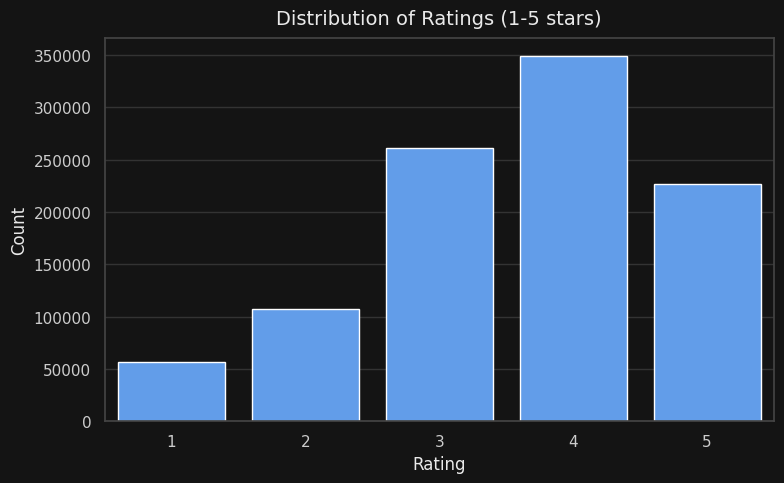

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(x=ratings['rating'], ax=ax, color='#4C9AFF')
ax.set_title('Distribution of Ratings (1-5 stars)', fontsize=14, color='#eaeaea', pad=10)
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

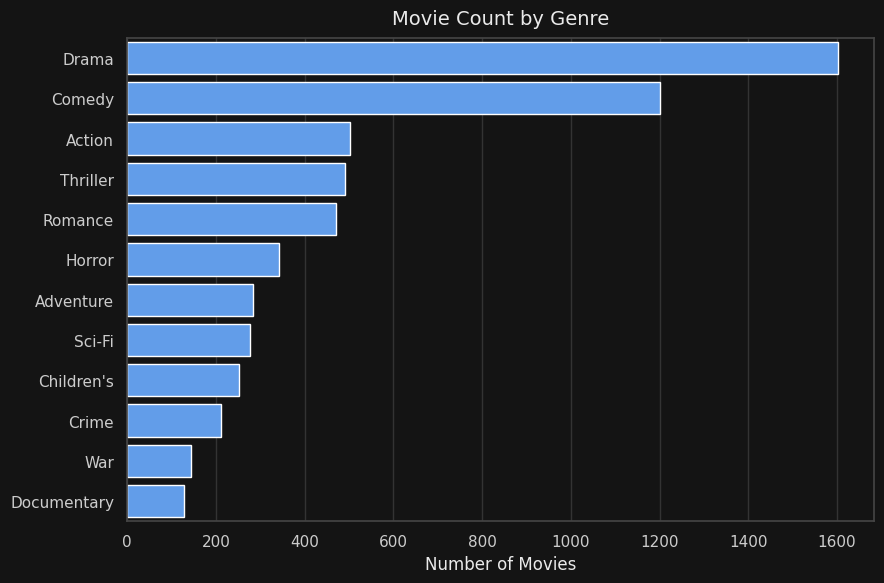

In [5]:
genres = movies['genres'].str.split('|').explode()
top_genres = genres.value_counts().head(12)

fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, color='#4C9AFF')
ax.set_title('Movie Count by Genre', fontsize=14, color='#eaeaea', pad=10)
ax.set_xlabel('Number of Movies')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

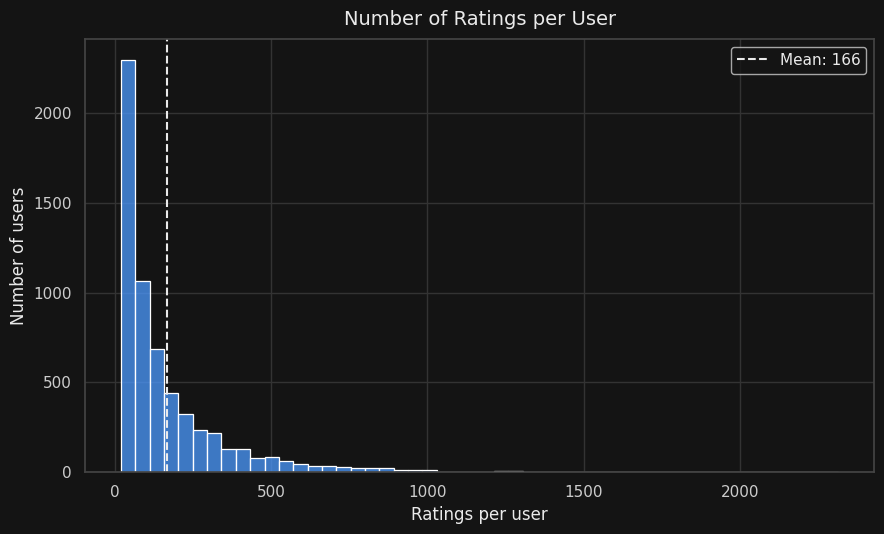

In [6]:
ratings_per_user = ratings.groupby('user_id').size()

fig, ax = plt.subplots(figsize=(9,5.5))
sns.histplot(ratings_per_user, bins=50, color='#4C9AFF', ax=ax)
ax.axvline(ratings_per_user.mean(), color='#eaeaea', linestyle='--', label=f"Mean: {ratings_per_user.mean():.0f}")
ax.set_title('Number of Ratings per User', fontsize=14, color='#eaeaea', pad=10)
ax.set_xlabel('Ratings per user')
ax.set_ylabel('Number of users')
ax.legend()
plt.tight_layout()
plt.show()

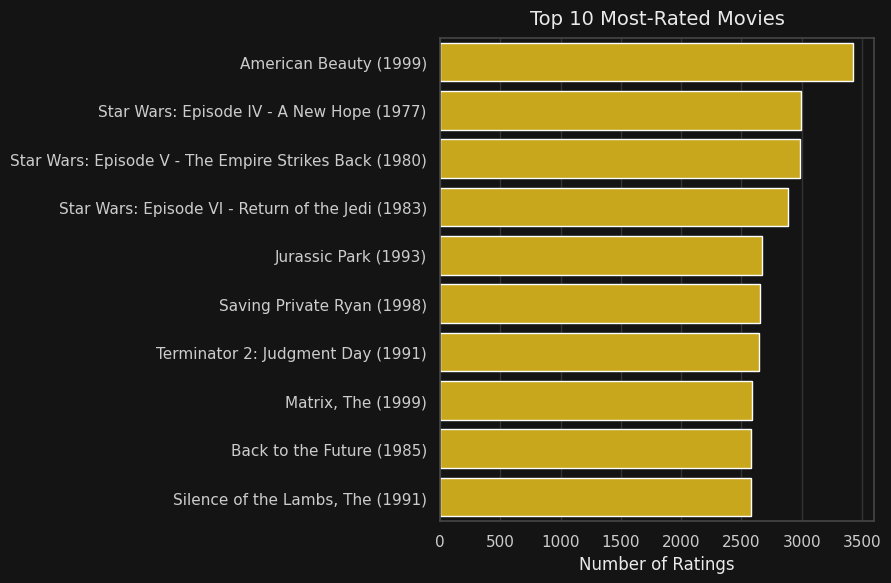

In [7]:
most_rated = ratings.groupby('movie_id').size().sort_values(ascending=False).head(10)
most_rated_titles = movies.set_index('movie_id').loc[most_rated.index, 'title']

fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(x=most_rated.values, y=most_rated_titles.values, ax=ax, color='#E6B800')
ax.set_title('Top 10 Most-Rated Movies', fontsize=14, color='#eaeaea', pad=10)
ax.set_xlabel('Number of Ratings')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Content-Based Model: TF-IDF on Genres

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)

tfidf = TfidfVectorizer(token_pattern=r"[^\s]+")
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

# quick sanity check: genre similarity for one movie
idx = movies[movies['title'] == 'Toy Story (1995)'].index[0]
sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).ravel()
top5 = sims.argsort()[::-1][1:6]
movies.iloc[top5][['title','genres']]

TF-IDF matrix shape: (3883, 18)


,title,genres
1050,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy
3682,Chicken Run (2000),Animation|Children's|Comedy
3685,"Adventures of Rocky and Bullwinkle, The (2000)",Animation|Children's|Comedy
3045,Toy Story 2 (1999),Animation|Children's|Comedy
2286,"Bug's Life, A (1998)",Animation|Children's|Comedy


Purely genre-based similarity is a reasonable start, but it has an obvious limitation: it can't tell *The Matrix* and a forgettable straight-to-DVD action movie apart if they share tags. That's what collaborative filtering fixes — it uses actual human taste, not just metadata.

## 4. Collaborative Filtering: Item-Based via Truncated SVD

In [9]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

movie_id_to_idx = {mid: i for i, mid in enumerate(movies['movie_id'])}
user_ids = ratings['user_id'].unique()
user_id_to_idx = {uid: i for i, uid in enumerate(user_ids)}

rows = ratings['movie_id'].map(movie_id_to_idx).values
cols = ratings['user_id'].map(user_id_to_idx).values
vals = ratings['rating'].values

item_user_matrix = csr_matrix((vals, (rows, cols)), shape=(len(movies), len(user_ids)))
print("Item-user matrix shape:", item_user_matrix.shape)

svd = TruncatedSVD(n_components=50, random_state=42)
item_factors = svd.fit_transform(item_user_matrix)
print("Item factors shape:", item_factors.shape)
print(f"Variance explained by 50 components: {svd.explained_variance_ratio_.sum()*100:.1f}%")

Item-user matrix shape: (3883, 6040)


Item factors shape: (3883, 50)
Variance explained by 50 components: 44.7%


In [10]:
# sanity check: collaborative-only similarity for the same movie
collab_sims = cosine_similarity(item_factors[idx].reshape(1,-1), item_factors).ravel()
top5 = collab_sims.argsort()[::-1][1:6]
movies.iloc[top5][['title','genres']]

,title,genres
3045,Toy Story 2 (1999),Animation|Children's|Comedy
33,Babe (1995),Children's|Comedy|Drama
2286,"Bug's Life, A (1998)",Animation|Children's|Comedy
584,Aladdin (1992),Animation|Children's|Comedy|Musical
1245,Groundhog Day (1993),Comedy|Romance


Notice the collaborative-only results pull in movies that *aren't* animated family films but that the same users tended to rate highly alongside Toy Story — a different, complementary signal to genre similarity.

## 5. Hybrid Recommender

In [11]:
from recommender import HybridRecommender

rec = HybridRecommender(movies[['movie_id','title','genres']], ratings, n_components=50)

matched_title, results = rec.recommend("Toy Story (1995)", top_n=10, content_weight=0.5)
print(f"Recommendations for: {matched_title}\n")
results

Recommendations for: Toy Story (1995)



,movie_id,title,genres,hybrid_score,avg_rating,rating_count
0,3114,Toy Story 2 (1999),Animation|Children's|Comedy,0.953688,4.22,1585
1,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,0.934873,3.85,1703
2,3751,Chicken Run (2000),Animation|Children's|Comedy,0.858521,3.88,1329
3,2294,Antz (1998),Animation|Children's,0.848804,3.48,645
4,2761,"Iron Giant, The (1999)",Animation|Children's,0.845931,4.05,674
5,588,Aladdin (1992),Animation|Children's|Comedy|Musical,0.834874,3.79,1351
6,2687,Tarzan (1999),Animation|Children's,0.833337,3.67,442
7,1907,Mulan (1998),Animation|Children's,0.822386,3.74,490
8,1064,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy,0.805806,2.89,209
9,3287,"Tigger Movie, The (2000)",Animation|Children's,0.803789,2.73,129


In [12]:
matched_title, results = rec.recommend("Star Wars: Episode IV - A New Hope (1977)", top_n=10, content_weight=0.4)
print(f"Recommendations for: {matched_title}\n")
results

Recommendations for: Star Wars: Episode IV - A New Hope (1977)



,movie_id,title,genres,hybrid_score,avg_rating,rating_count
0,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Fantasy|Sci-Fi,0.906886,3.41,2250
1,2105,Tron (1982),Action|Adventure|Fantasy|Sci-Fi,0.832133,3.36,970
2,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,0.821042,4.29,2990
3,2968,Time Bandits (1981),Adventure|Fantasy|Sci-Fi,0.808075,3.69,1010
4,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,0.789358,4.02,2883
5,2640,Superman (1978),Action|Adventure|Sci-Fi,0.788561,3.54,1222
6,480,Jurassic Park (1993),Action|Adventure|Sci-Fi,0.785305,3.76,2672
7,1198,Raiders of the Lost Ark (1981),Action|Adventure,0.772597,4.48,2514
8,1097,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi,0.767606,3.97,2269
9,1374,Star Trek: The Wrath of Khan (1982),Action|Adventure|Sci-Fi,0.762764,3.88,1448


## 6. Comparing Weightings

The `content_weight` parameter lets you slide between pure genre-matching (1.0) and pure "users like you" collaborative filtering (0.0). Below, the same movie at both extremes:

In [13]:
_, content_only = rec.recommend("Toy Story (1995)", top_n=5, content_weight=1.0)
_, collab_only = rec.recommend("Toy Story (1995)", top_n=5, content_weight=0.0)

comparison = pd.DataFrame({
    "Content-only (genre)": content_only['title'].values,
    "Collaborative-only (ratings)": collab_only['title'].values
})
comparison

,Content-only (genre),Collaborative-only (ratings)
0,"Rugrats Movie, The (1998)",Toy Story 2 (1999)
1,Aladdin and the King of Thieves (1996),Babe (1995)
2,Chicken Run (2000),"Bug's Life, A (1998)"
3,"Adventures of Rocky and Bullwinkle, The (2000)",Aladdin (1992)
4,Toy Story 2 (1999),Groundhog Day (1993)


## 7. Key Findings

- The ratings matrix is **95.7% sparse** — the average user has rated only ~166 of 3,883 movies, which is why naive similarity on raw ratings doesn't work well and dimensionality reduction (SVD) is needed.
- **Drama, Comedy, and Action** are the most common genres in the catalog.
- Content-based and collaborative filtering surface genuinely different — and complementary — recommendations for the same movie, which is the core motivation for a hybrid approach.
- The hybrid model successfully identifies sequels and genre-mates for franchise films (e.g. Toy Story → Toy Story 2, A Bug's Life, Chicken Run) while still incorporating real rating-pattern signals.

## 8. Try It Interactively

Run the companion Streamlit app for an interactive version of this recommender:

```bash
streamlit run app.py
```
